# **Laboratorio 4**

Integrantes del grupo
- Emmanuel Blanco - 202312743
- Juan David Guzmán - 202320890

### Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler

## **Carga de datos**

In [2]:
datos = pd.read_csv("Datos_VuelaAlpes.csv",sep=",")

print("Dimensiones de los datos")
print("Filas: ",datos.shape[0])
print("Columnas: ",datos.shape[1])

Dimensiones de los datos
Filas:  10000
Columnas:  23


## **Exploración de datos**

In [3]:
# Desplegamos el diccionario para entender que tipo de variables tenemos
diccionario = pd.read_excel("Diccionario VuelaAlpes.xlsx")
diccionario

,Variable,Tipo,Descripción
0,id,Entero,Identificador único del pasajero
1,Gender,Texto,Género del pasajero (Male / Female)
2,Customer Type,Texto,Tipo de cliente (Loyal Customer / disloyal Cus...
3,Age,Entero,Edad del pasajero
4,Type of Travel,Texto,Tipo de viaje (Business / Personal)
5,Class,Texto,"Clase del vuelo (Eco, Eco Plus, Business)"
6,Flight Distance,Entero,Distancia del vuelo
7,Inflight wifi service,Entero,Calificación del wifi (0–5)
8,Departure/Arrival time convenient,Entero,Conveniencia del horario (0–5)
9,Ease of Online booking,Entero,Facilidad de reserva online (0–5)


A primera vista podemos ver que la mayoría de las variables son categóricas, muchas de las variables representan una calificación de 0 a 5 en relación a un servicio.

Habiendo observado esto tenemos dos opciones, codificar las variables categóricas a números que el modelo sí pueda usar o hacer un modelamiento con alguna herramiento que permita manejar ambos tipos de variables

In [4]:
datos.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,9975.000000
mean,64983.058500,39.404300,1196.044800,2.734700,3.074000,2.762600,3.002800,3.215200,3.234500,3.431300,3.361900,3.391000,3.34440,3.635800,3.291700,3.643700,3.281200,14.86020,15.215439
std,37610.205164,15.072364,1000.590808,1.328718,1.520511,1.394287,1.283182,1.324486,1.350293,1.314935,1.329099,1.287123,1.31809,1.184271,1.263951,1.183085,1.311068,36.78467,37.370561
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,0.00000,0.000000
25%,32452.000000,27.000000,416.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,3.000000,2.000000,3.000000,2.000000,0.00000,0.000000
50%,64815.500000,40.000000,846.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.00000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,97470.000000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,5.000000,4.000000,5.000000,4.000000,13.00000,13.000000
max,129879.000000,80.000000,4963.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,930.00000,952.000000


In [5]:
# Revisamos los datos nulos

porcentajes_NaN = (datos.isnull().sum()/(datos.shape[0]*100)).sort_values(ascending=False)
info_faltante = pd.DataFrame({
    'Columna':porcentajes_NaN.index,
    'Total de datos faltantes':datos.isnull().sum()[porcentajes_NaN.index].values,
    '%':porcentajes_NaN.values
})
info_faltante[info_faltante['Total de datos faltantes']>0]

,Columna,Total de datos faltantes,%
0,Arrival Delay in Minutes,25,0.000025


Podemos ver que la variables Arrival Delay in minutes tiene filas vacías por lo que debemos completar esta columna

In [6]:
print(f"Registros duplicados: {datos.duplicated().sum()}")

Registros duplicados: 0


Revisaremos el formato de las entradas en Gender, Customer Type, Type of travel y Class

In [7]:
datos["Gender"].value_counts()

Gender
Female    5140
Male      4860
Name: count, dtype: int64

In [8]:
datos["Customer Type"].value_counts()

Customer Type
Loyal Customer       8155
disloyal Customer    1845
Name: count, dtype: int64

In [9]:
datos["Type of Travel"].value_counts()

Type of Travel
Business travel    6934
Personal Travel    3066
Name: count, dtype: int64

In [10]:
datos["Class"].value_counts()

Class
Business    4856
Eco         4442
Eco Plus     702
Name: count, dtype: int64

Revisamos la distribución de los datos de acuerdo a las variables

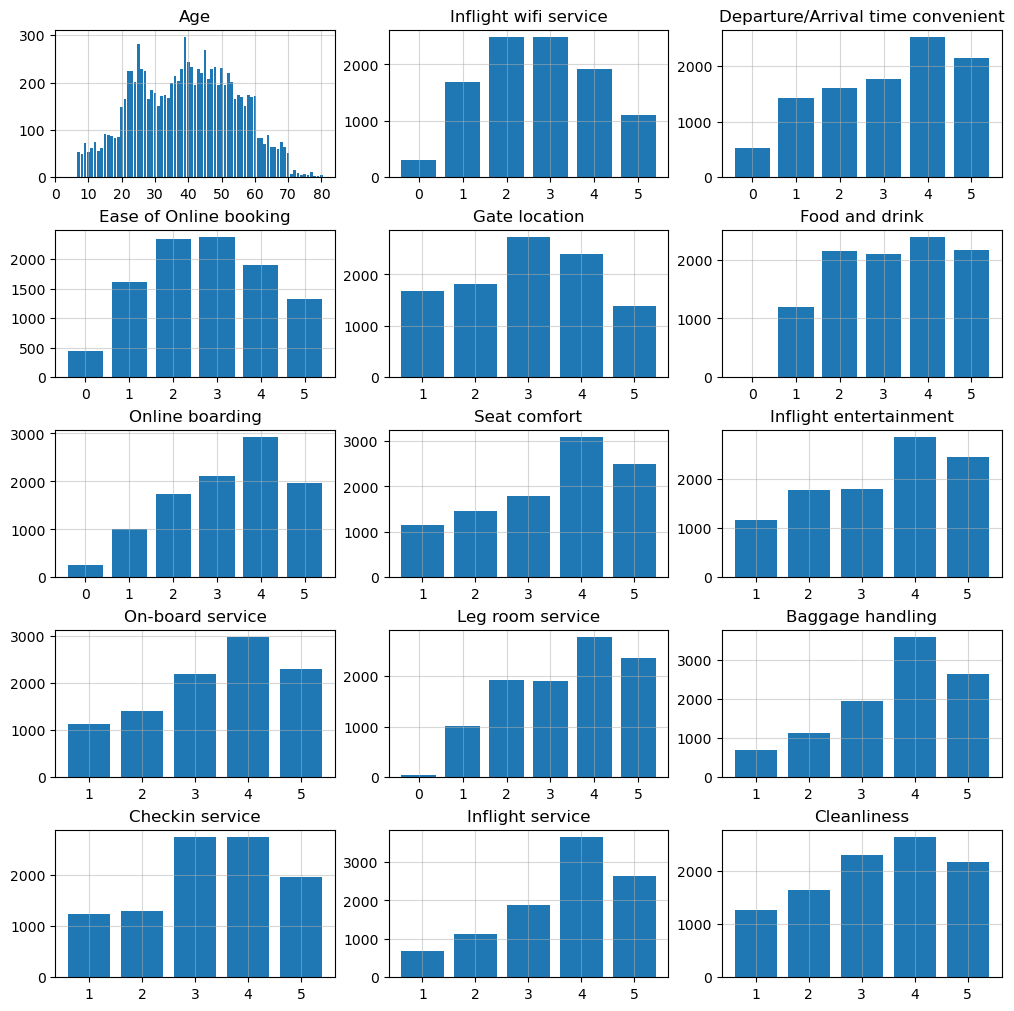

In [11]:
vars_hist = ["Flight Distance", "Departure Delay in Minutes"]
omitir = ["id","Flight Distance", "Departure Delay in Minutes","Arrival Delay in Minutes"]

vars_bar_plot = [
    col for col in datos.select_dtypes(include=[np.number]).columns
    if col not in omitir
]


fig, ax  = plt.subplots(5,3, layout="constrained",figsize=(10,10))

fila = 0
col = 0

for i in range(len(vars_bar_plot)):
    
    var = vars_bar_plot[i]
    counts = datos[var].value_counts()
    ax[fila][col].bar(counts.index,counts.values)
    ax[fila][col].grid(alpha=0.5)
    if var != "Age":
        ax[fila][col].set(title=var, xticks=counts.index)
    
    else:
        ax[fila][col].set(title=var, xticks= np.arange(0,81,10))
    
    if i == 2:
        fila = 1
        col = 0
    
    elif i == 5:
        fila = 2
        col = 0
    
    elif i == 8:
        fila = 3
        col = 0
        
    elif i == 11:
        fila = 4
        col = 0
    
    else:
        col+=1
        
plt.show()
    

Distribución Flight Distance
Intevalo de 0 a 31.0: 0.26%
Intervalos de 31.1 a 80.32: 2.28%
Intervalos de 80.42 a 129.64: 2.36%
Intervalos de 129.74 a 178.96: 4.39%
Intervalos de 179.06 a 228.28: 3.74%
Intervalos de 228.38 a 277.6: 3.85%
Intervalos de 277.7 a 326.92: 4.91%
Intervalos de 327.02 a 376.24: 4.03%
Intervalos de 376.34 a 425.56: 3.61%
Intervalos de 425.66 a 474.88: 2.73%
Intervalos de 474.98 a 524.2: 3.27%
Intervalos de 524.3 a 573.52: 3.86%
Intervalos de 573.62 a 622.84: 3.03%
Intervalos de 622.94 a 672.16: 2.14%
Intervalos de 672.26 a 721.48: 2.16%
Intervalos de 721.58 a 770.8: 2.19%
Intervalos de 770.9 a 820.12: 3.02%
Intervalos de 820.22 a 869.44: 1.46%
Intervalos de 869.54 a 918.76: 2.63%
Intervalos de 918.86 a 968.08: 2.58%
Intervalos de 968.18 a 1017.4: 1.79%
Intervalos de 1017.5 a 1066.72: 1.83%
Intervalos de 1066.82 a 1116.04: 1.07%
Intervalos de 1116.14 a 1165.36: 1.6%
Intervalos de 1165.46 a 1214.68: 0.96%
Intervalos de 1214.78 a 1264.0: 0.64%
Intervalos de 1264.1 

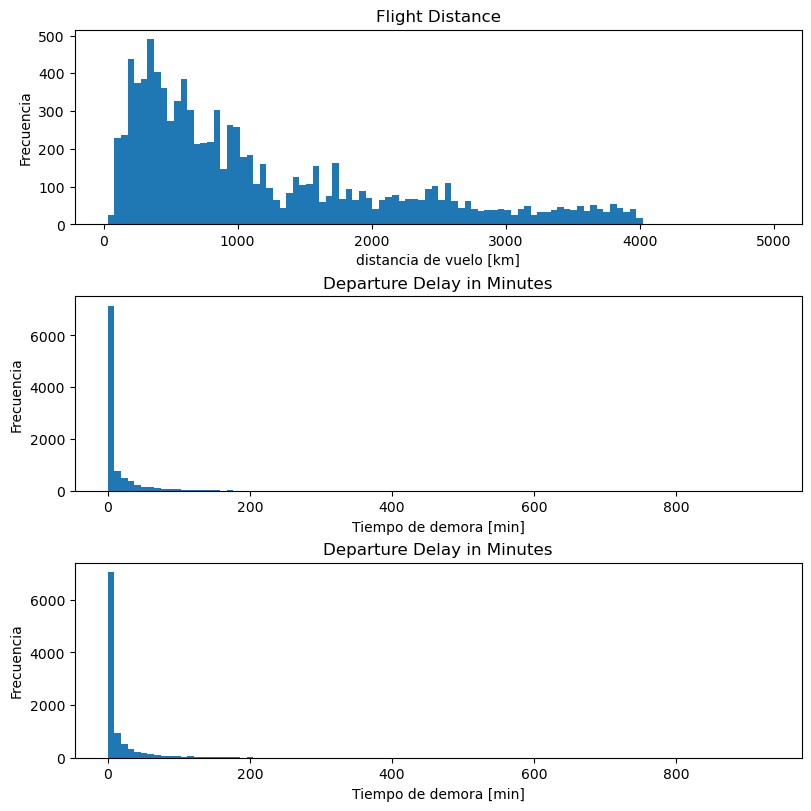

In [22]:
# Hacemos una copia de la columna Arrival Delay in Minutes para poder graficar la distribución de sus datos (eliminando las columnas con NaN)
arrival_delay = datos["Arrival Delay in Minutes"]

# Eliminamos los datos nulos
arrival_delay.dropna(inplace=True)

#Graficamos los histogramas de las variables continuas
fig, ax  = plt.subplots(3,1, layout="constrained",figsize=(8,8))

# En este diccionario guardaremos la division de los datos en intervalos para poder desplegar la porción del total que representa cada bin
particion_bins = {}

for i in range(len(vars_hist)):
    var = vars_hist[i]
    counts, bin_edges = np.histogram(datos[var], bins=100)
    ax[i].stairs(counts, bin_edges, fill=True)
    particion_bins[var] = (counts, bin_edges)
    if i == 0:
        ax[i].set(title=var, xlabel= "distancia de vuelo [km]", ylabel="Frecuencia")
    else:
        ax[i].set(title=var, xlabel="Tiempo de demora [min]", ylabel="Frecuencia")

counts, bin_egdes = np.histogram(arrival_delay,bins=100)
ax[2].stairs(counts, bin_edges, fill=True)
ax[2].set(title=var, xlabel= "Tiempo de demora [min]", ylabel="Frecuencia")
particion_bins["Arrival Delay in Minutes"] = (counts, bin_edges)


for key in particion_bins:
    print(f"Distribución {key}")
    counts, bin_edges = particion_bins[key]
    
    if key == "Arrival Delay in Minutes":
        for i in range(len(counts)):
            if i == 0:
                print(f"Intevalo de 0 a {round(bin_edges[i],3)}: {round((counts[i]/arrival_delay.shape[0])*100,3)}%")
            
            else:
                print(f"Intervalos de {round(bin_edges[i-1]+0.1,3)} a {round(bin_edges[i],3)}: {round((counts[i]/arrival_delay.shape[0])*100,3)}%")
    
    else:
        for i in range(len(counts)):
            if i == 0:
                print(f"Intevalo de 0 a {round(bin_edges[i],3)}: {round((counts[i]/datos.shape[0])*100,3)}%")
            else:
                print(f"Intervalos de {round(bin_edges[i-1]+0.1,3)} a {round(bin_edges[i],3)}: {round((counts[i]/datos.shape[0])*100,3)}%")
    
    print("\n")

plt.show()

Haciendo una inspección de los gráficos podemos identificar los siguiente:
- Las variables ordinales que califican distintos aspectos del servicio no parecen presentar muchos problemas, en algunas variables las calificaciones de 0 son muy pocas en comparación a las demás calificaciones. Pero en general no se presentarían muchos problemas con estas variables
- En la variable edad la mayoría de los datos se concentra entre los 20 y 60 años. Los datos entre 70 y 80 años parecen ser escasos, por lo que debemos tratar esto con cuidado
- Las demoras en Arrival y Departure son en su mayoría de valor 0, lo cual genera un gran desbalance en los datos de estas variables. Es muy posible que los datos con demoras de 100 min en adelante sean tomados como outliers. Por lo tanto hay que revisar como manejar estas variables a la hora de preparar los datos para usar modelos como K-means que son sensibles a los outliers
- En particular hay que tener cuidado con la imputación de valores faltantes en Arrival Delay por lo mencionado anteriormente respecto a los outliers, quizá sea mejor imputar la mediana o moda en lugar de imputar la media

## **Limpieza y Preparación de datos**

In [ ]:
# Necesitamos desarrollar 3 modelos, usaremos
# - K-means: es sensible a los outliers. Como hiperparámetros: k (num de clusters) y Funcion de distribuión
# - DBSCAN: hiperparámetros: eps (radio del circulo con el que identificaremos a los del mismo grupo) y mínimo de elementos para formar un grupo
# - Agglomerative (resulta en subgrupos de un total): hiperparámetros: n-clusters (que es equivalente al máximo nivel del dendograma)

# Aparte de estos podríamos utilizar K-medoides que también hace parte de scikit-learn, pero con lo jodido que es con la versión de python y de numpy mejor no usarlo

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import ParameterGrid

# 1. Eliminamos la columna 'id' que no nos aporta valor predictivo
if 'id' in datos.columns:
    datos_modelo = datos.drop('id', axis=1)
else:
    datos_modelo = datos.copy()

# 2. Defininimos ahor las columnas según su tipo
numeric_cols_outliers = ["Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
numeric_cols_standard = [col for col in datos_modelo.select_dtypes(include=[np.number]).columns if col not in numeric_cols_outliers]
categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]

# 3. Construimos el ColumnTransformer
    # Caso para numericas con outliers
    #Imputacion de mediana y RobustScaler
numeric_outliers_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Para numericas estandr tenemos imputacion de mediana y StandardScaler
numeric_standard_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Para categoricas, se ejerce imputacion de moda y OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_outliers', numeric_outliers_transformer, numeric_cols_outliers),
        ('num_std', numeric_standard_transformer, numeric_cols_standard),
        ('cat', categorical_transformer, categorical_cols)
    ])

#preprocesamiento a los datos
X_prep = preprocessor.fit_transform(datos_modelo)

# Muestr aleatoria para agrupamiento dado el costo computacional de DBSCAN o Agglomerative
import numpy as np
np.random.seed(42)
# Fixed: Adjusted sample size to be at most the population size (X_prep.shape[0])
sample_size = min(15000, X_prep.shape[0]) # Ensure sample_size does not exceed population
sample_indices = np.random.choice(X_prep.shape[0], size=sample_size, replace=False)
X_sample = X_prep[sample_indices]

print(f"Dimensiones completos: {X_prep.shape}")
print(f"Dimensiones muestra: {X_sample.shape}")

## **Modelamiento**

1. K-MEANS

In [ ]:
import time

resultados_modelos = []

print("Entrenando KMeans...")
start_time = time.time()
kmeans_params = {'n_clusters': [2, 3, 4, 5]}
best_kmeans_score = -1
best_kmeans_model = None

for k in kmeans_params['n_clusters']:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    print(f"KMeans (k={k}) - Silueta: {score:.4f}")
    
    if score > best_kmeans_score:
        best_kmeans_score = score
        best_kmeans_model = kmeans

resultados_modelos.append({
    'Modelo': 'K-Means', 
    'Mejores Hiperparámetros': f"k={best_kmeans_model.n_clusters}", 
    'Silhouette Score': best_kmeans_score,
    'Tiempo (s)': time.time() - start_time
})

2. DBSCAN

In [ ]:
import time

resultados_modelos = []
print("\nEntrenando DBSCAN...")
start_time = time.time()
dbscan_params = {'eps': [1.5, 2.0, 2.5], 'min_samples': [5, 10, 15]}
best_dbscan_score = -1
best_dbscan_model = None

for params in ParameterGrid(dbscan_params):
    dbscan = DBSCAN(**params)
    labels = dbscan.fit_predict(X_sample)
    
    if len(set(labels)) > 1:
        score = silhouette_score(X_sample, labels)
    else:
        score = -1
        
    print(f"DBSCAN (eps={params['eps']}, min_samples={params['min_samples']}) - Silueta: {score:.4f} - Clusters: {len(set(labels))}")
    
    if score > best_dbscan_score:
        best_dbscan_score = score
        best_dbscan_model = dbscan

resultados_modelos.append({
    'Modelo': 'DBSCAN', 
    'Mejores Hiperparámetros': f"eps={best_dbscan_model.eps}, min_samples={best_dbscan_model.min_samples}", 
    'Silhouette Score': best_dbscan_score,
    'Tiempo (s)': time.time() - start_time
})

3. AGGLOMERATIVE CLUSTERING

In [ ]:
import time

resultados_modelos = []

print("\nEntrenando Agglomerative Clustering...")
start_time = time.time()
agg_params = {'n_clusters': [2, 3, 4, 5]}
best_agg_score = -1
best_agg_model = None

for k in agg_params['n_clusters']:
    agg = AgglomerativeClustering(n_clusters=k)
    labels = agg.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    print(f"Agglomerative (k={k}) - Silueta: {score:.4f}")
    
    if score > best_agg_score:
        best_agg_score = score
        best_agg_model = agg

resultados_modelos.append({
    'Modelo': 'Agglomerative', 
    'Mejores Hiperparámetros': f"k={best_agg_model.n_clusters}", 
    'Silhouette Score': best_agg_score,
    'Tiempo (s)': time.time() - start_time
})

## **Análisis de resultados**

### **Evaluación cuantitativa**

In [ ]:
# Análisis de silueta para K-means
import pandas as pd
df_resultados = pd.DataFrame(resultados_modelos)
df_resultados.sort_values(by='Silhouette Score', ascending=False, inplace=True)
display(df_resultados)

### **Evaluación cualitativa**

In [ ]:
#árboles, centroides, boxplots
from sklearn.tree import DecisionTreeClassifier, plot_tree

# KMeans fue el mejor modelo para interpretar (mayor silueta y grupos balanceados)
best_labels = best_kmeans_model.fit_predict(X_sample)

# Agregamos las etiquetas a nuestra muestra original para interpretar
df_sample = datos_modelo.iloc[sample_indices].copy()
df_sample['Cluster'] = best_labels

# Boxplots
vars_to_plot = ["Age", "Flight Distance", "Inflight wifi service", "Cleanliness", "Overall Quality"]
fig, axes = plt.subplots(1, len(vars_to_plot), figsize=(20, 5))
for i, var in enumerate(vars_to_plot):
    if var in df_sample.columns:
        sns.boxplot(x='Cluster', y=var, data=df_sample, ax=axes[i], palette='viridis')
        axes[i].set_title(f"Distribución de {var}")
plt.tight_layout()
plt.show()

# Árbol de decisión explicativo
print("Entrenando Árbol de Decisión explicativo...")
dt_explainer = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_explainer.fit(X_sample, best_labels)

# Obtener nombres de las características preprocesadas
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_features = cat_encoder.get_feature_names_out(categorical_cols)
feature_names = numeric_cols_outliers + numeric_cols_standard + list(cat_features)

plt.figure(figsize=(25, 10))
plot_tree(dt_explainer, feature_names=feature_names, class_names=[f"C{i}" for i in np.unique(best_labels)], filled=True, rounded=True, proportion=True, fontsize=10)
plt.title("Árbol de decisión explicativo de Clústeres")
plt.show()

# Importancia
importances = dt_explainer.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 5))
plt.title("Top 10 Características más importantes para definir Clústeres")
plt.bar(range(10), importances[indices], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Respuestas a las preguntas de Análisis de Resultados

**1. ¿Qué restricciones tiene cada uno de los algoritmos seleccionados? ¿Cómo afectan estas restricciones la calidad de la solución obtenida?**
- **K-Means**: Es sensible a outliers y asume clusteres esfericos. Su calidad baja si los grupos reales tienen formas irregulares.
- **DBSCAN**: En este caso escala mal en memoria ($O(n^2)$) lo que nos obligó a usar una muestra. Es muy sensible a los hiperparámetros `eps` y `min_samples`.
- **Agglomerative Clustering**: Sufre graves restricciones de memoria/tiempo ($O(n^3)$ en peor caso) al requerir la matriz de distancias completa.

**2. ¿Qué criterios son importantes para la selección del algoritmo?**
- Escalabilidad computacional (para grandes volúmenes K-Means es mucho mejor).
- Forma esperada de los clústeres (K-Means para esféricos, DBSCAN para densidad que son arbitrarias).
- Interpretabilidad de cara al negocio pues K-Means arroja un $K$ claro y fácil de entender.
- Por ult. la resistencia al ruido.

**3. ¿Cómo medir la calidad del modelo construido? ¿Cómo saber que el modelo construido tiene una buena calidad?**
- Mediante metricas intrinsecas como el **Coeficiente de Silueta**, pues sabemos que es de buena calidad si el coeficiente es positivo y cercano a 1 (buena cohesión y separación).

**4. ¿Cómo varía la calidad de la solución obtenida si se aplican diferentes algoritmos?**
- Varia drasticamente debido al metodo matematico base, ya que K-Means intenta agrupar equitativamente mientras DBSCAN puede etiquetar la mayor parte como "ruido" si el `eps` no captura la densidad correcta, afectando fuertemente y claramente el coeficiente de Silueta.

**5. ¿Cómo interpretar el resultado de la ejecución de los algoritmos de agrupación seleccionados?**
- Utilizando la tecnica de reglas generadas por el Árbol de Decisión y los boxplots. Podemos observar que ciertas combinaciones de servicios (ejemplo clarito Inflight wifi, Age) definen clusteres Premium o Basicos que le dan a VuelaAlpes el perfil exacto para tomar decisiones de negocio y entrenar tripulación.

## **Enlace al video explicativo de los resultados**

*enlace aquí*

In [ ]:
- **Aportes propios del estudiante**: La lógica base (como usar la mediana para 'Arrival Delay' debido a outliers detectados durante la exploración) provino de nuestro análisis EDA previo. Adaptamos las interpretaciones de la IAG (mediante árboles) al contexto real de VuelaAlpes.
- **Limitaciones**: La muestra de 15,000 registros se tomó por limitaciones computacionales, lo que podria afectar la representatividad de los clusteres. Además, la interpretación mediante árboles es una aproximación y no garantiza una explicación perfecta de los grupos formados.